<a href="https://colab.research.google.com/github/Shifana-22/Data-Analysis-Projects/blob/main/EDAStroke_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import scipy
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Stroke_analysis.csv')
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [ ]:
import scipy

In [ ]:
df.info

<bound method DataFrame.info of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban 

In [ ]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type            171
Residence_type       160
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Handling null values

In [ ]:
mean_bmi = df['bmi'].mean()
df['bmi'].fillna(mean_bmi, inplace=True)

# Print the updated DataFrame
print(df)


         id  gender   age  hypertension  heart_disease  avg_glucose_level  \
0      9046       1  67.0             0              1             228.69   
1     51676       0  61.0             0              0             202.21   
2     31112       1  80.0             0              1             105.92   
3     60182       0  49.0             0              0             171.23   
4      1665       0  79.0             1              0             174.12   
...     ...     ...   ...           ...            ...                ...   
5105  18234       0  80.0             1              0              83.75   
5106  44873       0  81.0             0              0             125.20   
5107  19723       0  35.0             0              0              82.99   
5108  37544       1  51.0             0              0             166.29   
5109  44679       0  44.0             0              0              85.28   

            bmi  smoking_status  stroke  
0     36.600000               1  

Dropping attributes that has missing values

In [ ]:
columns_to_drop = ['ever_married', 'work_type','Residence_type']
df.drop(columns=columns_to_drop, inplace=True)
print(df)  # Print the updated DataFrame

KeyError: ignored

In [ ]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [ ]:
columns_to_drop = ['Residence_type']
df.drop(columns=columns_to_drop, inplace=True)
print(df)  # Print the updated DataFrame

         id  gender   age  hypertension  heart_disease  avg_glucose_level  \
0      9046    Male  67.0             0              1             228.69   
1     51676  Female  61.0             0              0             202.21   
2     31112    Male  80.0             0              1             105.92   
3     60182  Female  49.0             0              0             171.23   
4      1665  Female  79.0             1              0             174.12   
...     ...     ...   ...           ...            ...                ...   
5105  18234  Female  80.0             1              0              83.75   
5106  44873  Female  81.0             0              0             125.20   
5107  19723  Female  35.0             0              0              82.99   
5108  37544    Male  51.0             0              0             166.29   
5109  44679  Female  44.0             0              0              85.28   

            bmi   smoking_status  stroke  
0     36.600000  formerly smoked

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_cols = ['gender', 'smoking_status','hypertension_cat','avg_glucose_level_cat','severity_cat','bmi_cat']
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Extract features
features = df.drop(columns=['stroke'])

# Extract labels (target variable) - 'stroke' column
labels = df['stroke']

# Print the extracted features and labels
print("Features:")
print(features.head())
print("\nLabels:")
print(labels.head())


Features:
   gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0       1  67.0             0              1             228.69  36.600000   
1       0  61.0             0              0             202.21  28.893237   
2       1  80.0             0              1             105.92  32.500000   
3       0  49.0             0              0             171.23  34.400000   
4       0  79.0             1              0             174.12  24.000000   

   smoking_status  hypertension_cat  avg_glucose_level_cat  severity_cat  \
0               1                 0                      0             1   
1               2                 0                      0             1   
2               2                 0                      1             1   
3               3                 0                      2             1   
4               2                 1                      2             1   

   bmi_cat  
0        0  
1        0  
2        0  
3        0  

In [ ]:
df.to_csv('cleaned_stroke.csv', index=True)

Statistical Analysis

In [ ]:
df.describe()

,id,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,0.414286,43.226614,0.097456,0.054012,106.147677,28.893237,1.376908,0.048728
std,21161.721625,0.493044,22.612647,0.296607,0.226063,45.283560,7.698018,1.071534,0.215320
min,67.000000,0.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000
25%,17741.250000,0.000000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000,0.000000
50%,36932.000000,0.000000,45.000000,0.000000,0.000000,91.885000,28.400000,2.000000,0.000000
75%,54682.000000,1.000000,61.000000,0.000000,0.000000,114.090000,32.800000,2.000000,0.000000
max,72940.000000,2.000000,82.000000,1.000000,1.000000,271.740000,97.600000,3.000000,1.000000


Check for outliers

TypeError: ignored

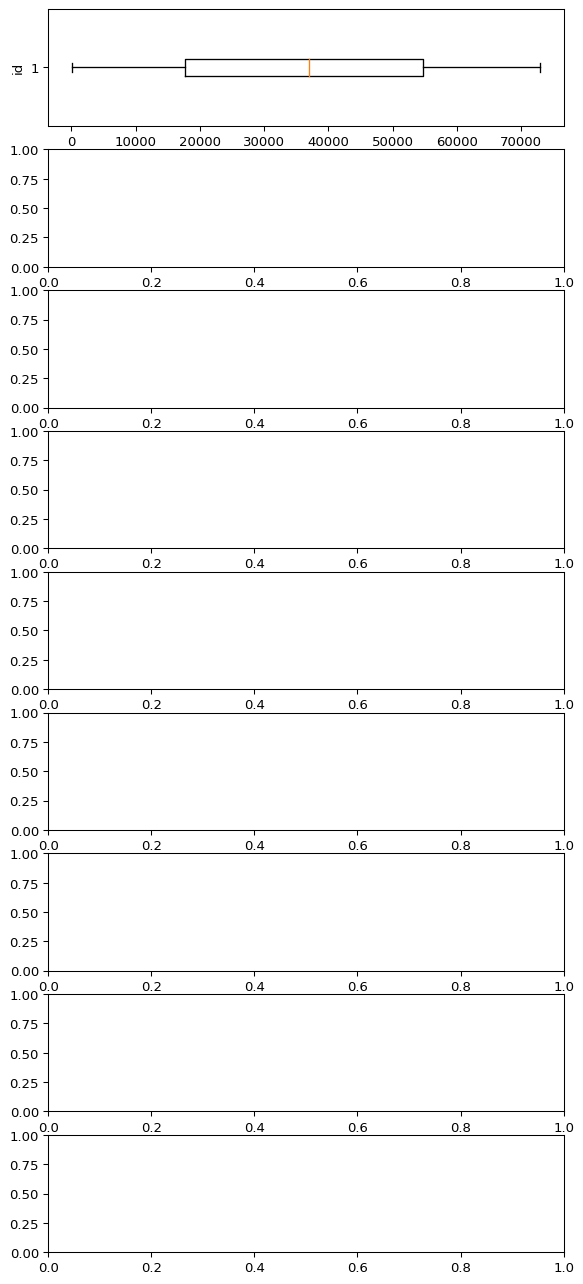

In [ ]:
fig, axs = plt.subplots(9,1,dpi=95, figsize=(7,17))
i = 0
for col in df.columns:
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
    i+=1
plt.show()

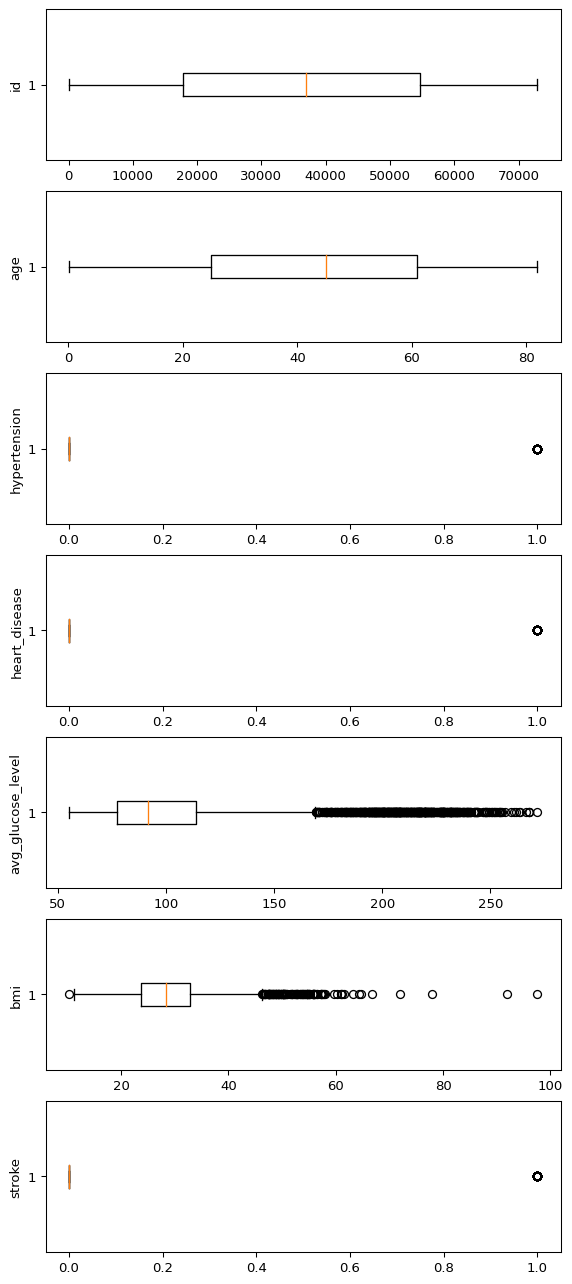

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Select columns that contain numerical data
numeric_columns = df.select_dtypes(include=['number']).columns

# Create subplots for the numeric columns
fig, axs = plt.subplots(len(numeric_columns), 1, dpi=95, figsize=(7, 17))

# Iterate through the numeric columns and create boxplots
for i, col in enumerate(numeric_columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()


Correaltion

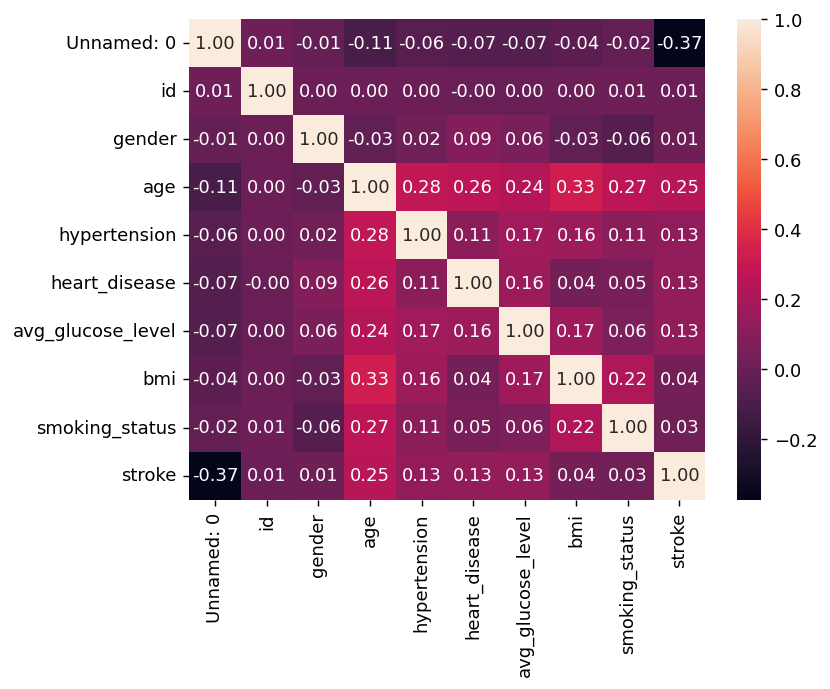

In [ ]:
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(df.corr(), annot=True, fmt= '.2f')
plt.show()

In [ ]:
# Assuming 'hypertension' and 'stroke' are the columns you want to correlate
correlation = df['hypertension'].corr(df['stroke'])

# Print the correlation
print(f"Correlation between 'hypertension' and 'stroke': {correlation}")


Correlation between 'hypertension' and 'stroke': 0.1279038234664799


In [ ]:
corr['stroke'].sort_values(ascending = False)

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.038947
id                   0.006388
Name: stroke, dtype: float64

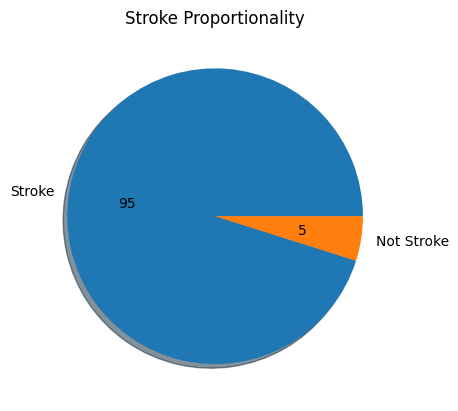

In [ ]:
plt.pie(df.stroke.value_counts(),
        labels= ['Stroke', 'Not Stroke'],
        autopct='%.f', shadow=True)
plt.title('Stroke Proportionality')
plt.show()

In [ ]:
X = df[['hypertension']]
Y = df['stroke']

print(X)
print(Y)

      hypertension
0                0
1                0
2                0
3                0
4                1
...            ...
5105             1
5106             0
5107             0
5108             0
5109             0

[5110 rows x 1 columns]
0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64


Normalization

In [ ]:
# initialising the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# learning the statistical parameters for each of the data and transforming
rescaledX = scaler.fit_transform(X)
rescaledX[:5]


array([[0.],
       [0.],
       [0.],
       [0.],
       [1.]])

Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
rescaledX = scaler.transform(X)
rescaledX[:5]


array([[-0.32860186],
       [-0.32860186],
       [-0.32860186],
       [-0.32860186],
       [ 3.04319637]])

In [ ]:
df.shape

(5110, 9)

In [ ]:
import pandas as pd
from sklearn.preprocessing import Binarizer

# Create a dataframe
dT = pd.DataFrame({
    'hypertension': [1, 0, 1, 0, 1]
})

# Create a binarizer object
binarizer = Binarizer(threshold=0.0)

# Fit the binarizer to the data
binarizer.fit(dT)

# Transform the data
binary_data = binarizer.transform(dT)

# Print the first 5 rows of the transformed data
print(binary_data[0:5,:])


[[1]
 [0]
 [1]
 [0]
 [1]]


Visulaizing data

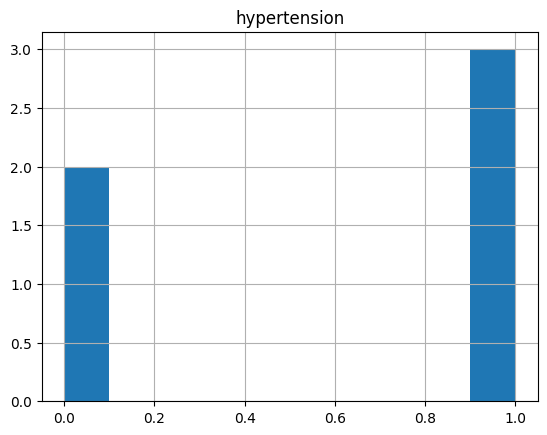

In [ ]:
>>> import matplotlib.pyplot as plt
>>> df.hist()
>>> plt.show()

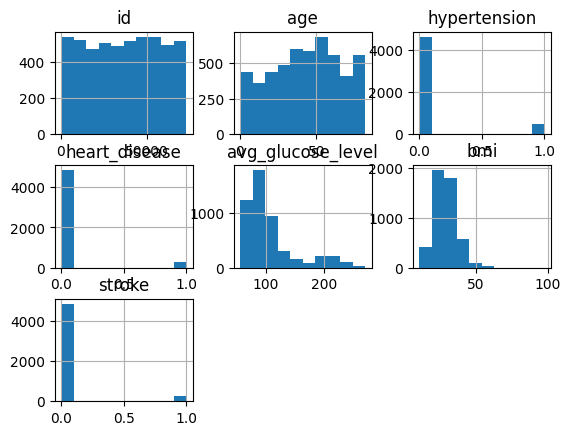

In [ ]:
df = pd.read_csv('analysisstroke.csv')
df.hist()

# Show the plot
plt.show()

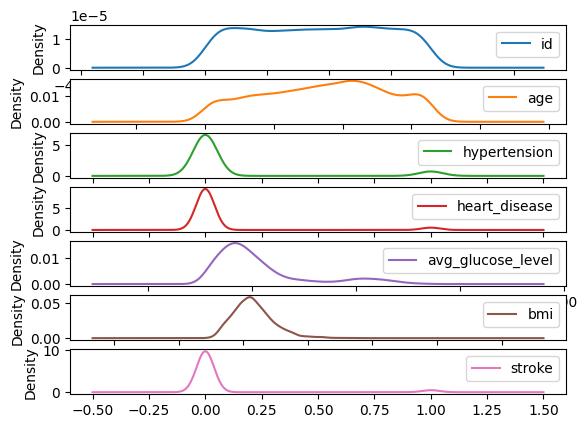

In [ ]:
df.plot(kind='density',subplots=True,sharex=False)
plt.show()

id                      Axes(0.125,0.11;0.0945122x0.77)
age                  Axes(0.238415,0.11;0.0945122x0.77)
hypertension         Axes(0.351829,0.11;0.0945122x0.77)
heart_disease        Axes(0.465244,0.11;0.0945122x0.77)
avg_glucose_level    Axes(0.578659,0.11;0.0945122x0.77)
bmi                  Axes(0.692073,0.11;0.0945122x0.77)
stroke               Axes(0.805488,0.11;0.0945122x0.77)
dtype: object

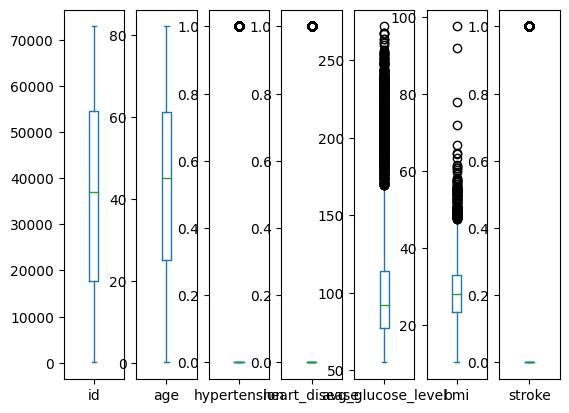

In [ ]:
>>> df.plot(kind='box',subplots=True,sharex=False,sharey=False)

array([[<Axes: xlabel='id', ylabel='id'>,
        <Axes: xlabel='age', ylabel='id'>,
        <Axes: xlabel='hypertension', ylabel='id'>,
        <Axes: xlabel='heart_disease', ylabel='id'>,
        <Axes: xlabel='avg_glucose_level', ylabel='id'>,
        <Axes: xlabel='bmi', ylabel='id'>,
        <Axes: xlabel='stroke', ylabel='id'>],
       [<Axes: xlabel='id', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='hypertension', ylabel='age'>,
        <Axes: xlabel='heart_disease', ylabel='age'>,
        <Axes: xlabel='avg_glucose_level', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='stroke', ylabel='age'>],
       [<Axes: xlabel='id', ylabel='hypertension'>,
        <Axes: xlabel='age', ylabel='hypertension'>,
        <Axes: xlabel='hypertension', ylabel='hypertension'>,
        <Axes: xlabel='heart_disease', ylabel='hypertension'>,
        <Axes: xlabel='avg_glucose_level', ylabel='hypertension'>,
        <Axes: xlabel=

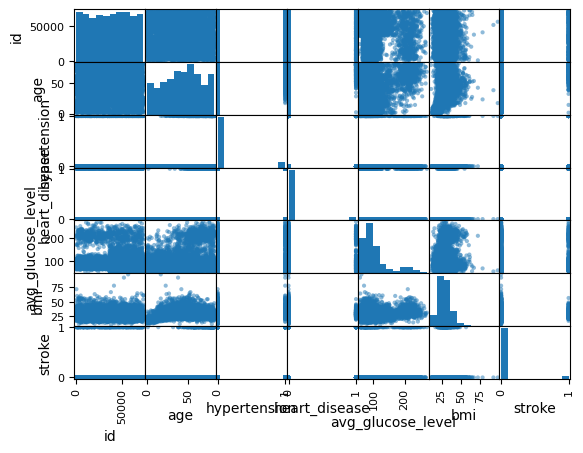

In [ ]:
>>> pd.plotting.scatter_matrix(df)

BINARIZATION OF DATA

In [ ]:

df['hypertension_cat'] = pd.cut(df['hypertension'], 2, labels=['no', 'yes'])
df['avg_glucose_level_cat'] = pd.cut(df['avg_glucose_level'], 3, labels=['low', 'medium', 'high'])
print(df)

      gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0          1  67.0             0              1             228.69  36.600000   
1          0  61.0             0              0             202.21  28.893237   
2          1  80.0             0              1             105.92  32.500000   
3          0  49.0             0              0             171.23  34.400000   
4          0  79.0             1              0             174.12  24.000000   
...      ...   ...           ...            ...                ...        ...   
5105       0  80.0             1              0              83.75  28.893237   
5106       0  81.0             0              0             125.20  40.000000   
5107       0  35.0             0              0              82.99  30.600000   
5108       1  51.0             0              0             166.29  25.600000   
5109       0  44.0             0              0              85.28  26.200000   

      smoking_status  strok

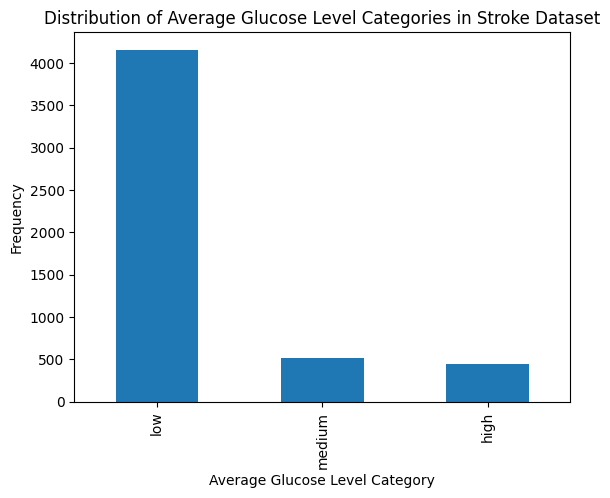

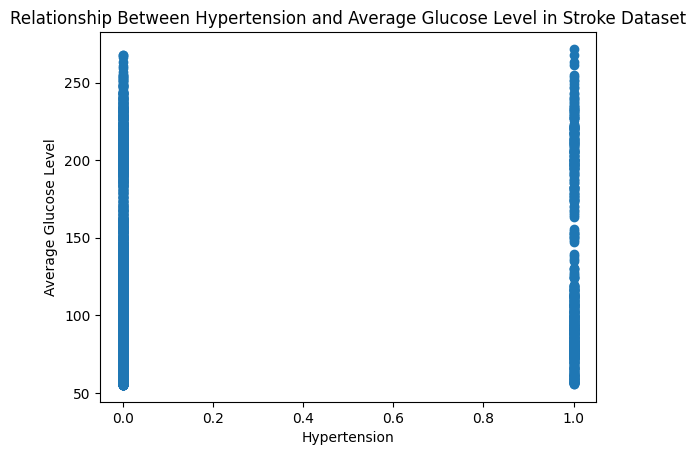

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Create a stacked bar chart of the average_glucose_level categories
df['avg_glucose_level_cat'].value_counts().plot(kind='bar')
plt.xlabel('Average Glucose Level Category')
plt.ylabel('Frequency')
plt.title('Distribution of Average Glucose Level Categories in Stroke Dataset')
plt.show()

# Create a scatter plot of the hypertension and avg_glucose_level variables
plt.scatter(df['hypertension'], df['avg_glucose_level'])
plt.xlabel('Hypertension')
plt.ylabel('Average Glucose Level')
plt.title('Relationship Between Hypertension and Average Glucose Level in Stroke Dataset')
plt.show()


ORDINAL CATEGORIZATION

In [ ]:
# Create a new column for the ordinal severity of stroke
df['severity_cat'] = pd.cut(df['stroke'], 3, labels=['mild', 'moderate', 'severe'])

# Print the dataframe to see the ordinal categorized data
print(df)


      gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0          1  67.0             0              1             228.69  36.600000   
1          0  61.0             0              0             202.21  28.893237   
2          1  80.0             0              1             105.92  32.500000   
3          0  49.0             0              0             171.23  34.400000   
4          0  79.0             1              0             174.12  24.000000   
...      ...   ...           ...            ...                ...        ...   
5105       0  80.0             1              0              83.75  28.893237   
5106       0  81.0             0              0             125.20  40.000000   
5107       0  35.0             0              0              82.99  30.600000   
5108       1  51.0             0              0             166.29  25.600000   
5109       0  44.0             0              0              85.28  26.200000   

      smoking_status  strok

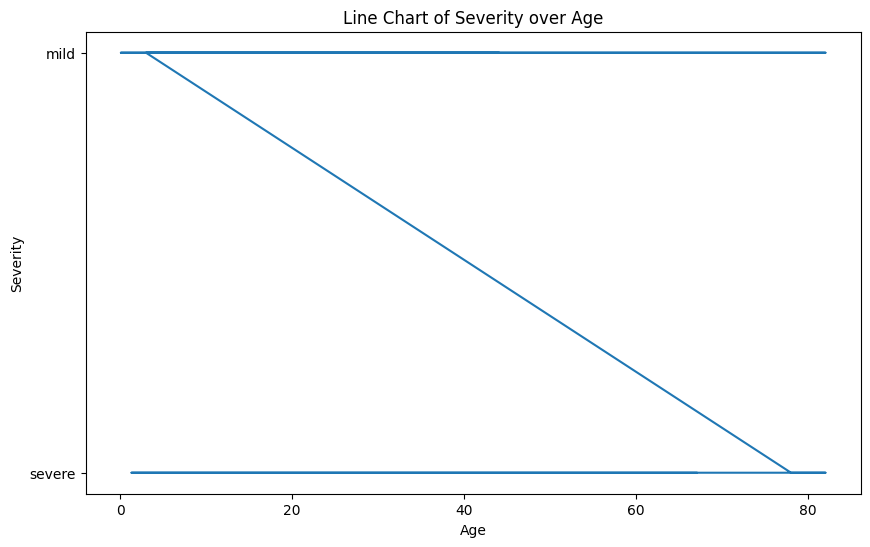

In [ ]:

# Create a line chart
plt.figure(figsize=(10, 6))
plt.plot(df['age'], df['severity_cat'])

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Severity')
plt.title('Line Chart of Severity over Age')
plt.show()



In [ ]:
df['bmi_cat'] = pd.cut(df['bmi'], 6, labels=['Underweight', 'Normal weight', 'Overweight', 'Obese Class I', 'Obese Class II', 'Obese Class III'])

# Print the dataframe
print(df)

      gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0          1  67.0             0              1             228.69  36.600000   
1          0  61.0             0              0             202.21  28.893237   
2          1  80.0             0              1             105.92  32.500000   
3          0  49.0             0              0             171.23  34.400000   
4          0  79.0             1              0             174.12  24.000000   
...      ...   ...           ...            ...                ...        ...   
5105       0  80.0             1              0              83.75  28.893237   
5106       0  81.0             0              0             125.20  40.000000   
5107       0  35.0             0              0              82.99  30.600000   
5108       1  51.0             0              0             166.29  25.600000   
5109       0  44.0             0              0              85.28  26.200000   

      smoking_status  strok

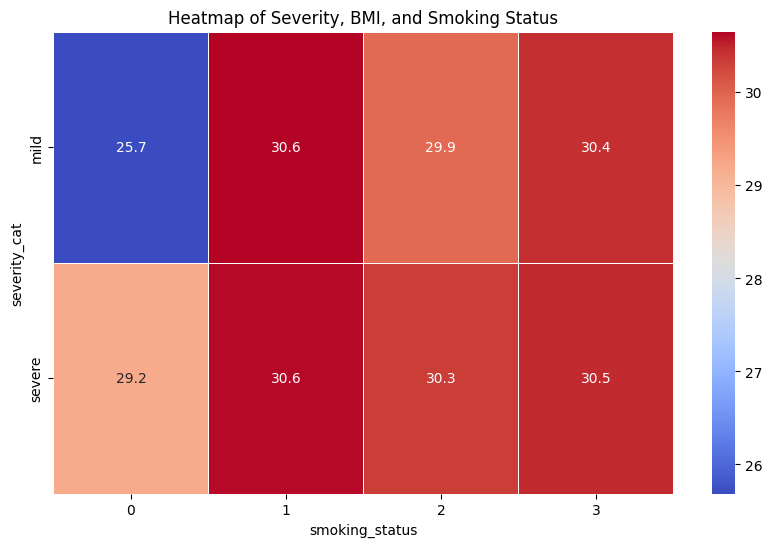

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame containing the data
# Make sure to have 'severity_cat,' 'bmi,' and 'smoking_status' columns

# Pivot the data to create a pivot table
pivot_table = df.pivot_table(index='severity_cat', columns='smoking_status', values='bmi', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".1f", linewidths=0.5)
plt.title('Heatmap of Severity, BMI, and Smoking Status')
plt.show()


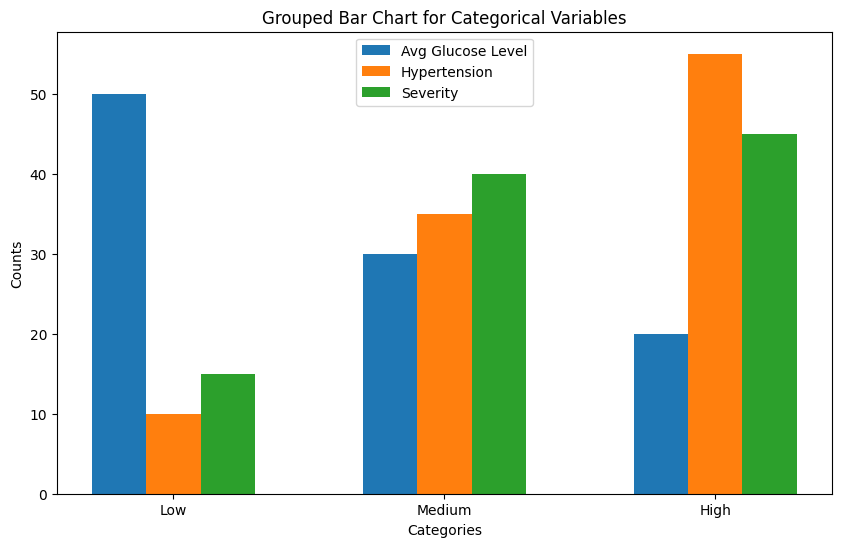

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your data)
categories = ['Low', 'Medium', 'High']
avg_glucose_counts = [50, 30, 20]  # Replace with your counts for each category
hypertension_counts = [10, 35, 55]  # Replace with your counts for each category
severity_counts = [15, 40, 45]  # Replace with your counts for each category

# Create an index for the x-axis (the number of categories)
x = np.arange(len(categories))

# Define the width of the bars
bar_width = 0.2

# Create the grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, avg_glucose_counts, bar_width, label='Avg Glucose Level')
plt.bar(x, hypertension_counts, bar_width, label='Hypertension')
plt.bar(x + bar_width, severity_counts, bar_width, label='Severity')

# Add labels, title, and legend
plt.xlabel('Categories')
plt.ylabel('Counts')
plt.title('Grouped Bar Chart for Categorical Variables')
plt.xticks(x, categories)
plt.legend()

plt.show()


In [ ]:
df.to_csv('modified_stroke_analysis.csv', index=False)


In [ ]:
from google.colab import files
files.download('modified_stroke_analysis.csv')


FileNotFoundError: ignored

In [ ]:
import pandas as pd

df = pd.read_csv('/content/modified_stroke_analysis.csv')
print(df.head())
numeric_summary = df[['age', 'avg_glucose_level', 'bmi']].describe()
print(numeric_summary)

   gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0       1  67.0             0              1             228.69  36.600000   
1       0  61.0             0              0             202.21  28.893237   
2       1  80.0             0              1             105.92  32.500000   
3       0  49.0             0              0             171.23  34.400000   
4       0  79.0             1              0             174.12  24.000000   

   smoking_status  stroke hypertension_cat avg_glucose_level_cat severity_cat  \
0               1       1               no                  high       severe   
1               2       1               no                  high       severe   
2               2       1               no                   low       severe   
3               3       1               no                medium       severe   
4               2       1              yes                medium       severe   

         bmi_cat  
0  Normal weight  
1  Nor

In [ ]:
stroke_percentage = (df['stroke'].sum() / len(df)) * 100
hypertension_percentage = (df['hypertension'].sum() / len(df)) * 100
heart_disease_percentage = (df['heart_disease'].sum() / len(df)) * 100
print(f"Stroke Percentage: {stroke_percentage:.2f}%")
print(f"Hypertension Percentage: {hypertension_percentage:.2f}%")
print(f"Heart Disease Percentage: {heart_disease_percentage:.2f}%")

Stroke Percentage: 4.87%
Hypertension Percentage: 9.75%
Heart Disease Percentage: 5.40%


In [ ]:
df.info

<bound method DataFrame.info of       gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0          1  67.0             0              1             228.69  36.600000   
1          0  61.0             0              0             202.21  28.893237   
2          1  80.0             0              1             105.92  32.500000   
3          0  49.0             0              0             171.23  34.400000   
4          0  79.0             1              0             174.12  24.000000   
...      ...   ...           ...            ...                ...        ...   
5105       0  80.0             1              0              83.75  28.893237   
5106       0  81.0             0              0             125.20  40.000000   
5107       0  35.0             0              0              82.99  30.600000   
5108       1  51.0             0              0             166.29  25.600000   
5109       0  44.0             0              0              85.28  26.200000

In [ ]:
# Assuming 'df' is your DataFrame

# Selecting numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
numerical_data = df[numerical_cols]

# Selecting categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_data = df[categorical_cols]

# Print the numerical and categorical data
print("Numerical Data:")
print(numerical_data.head())

print("\nCategorical Data:")
print(categorical_data.head())


Numerical Data:
   gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0       1  67.0             0              1             228.69  36.600000   
1       0  61.0             0              0             202.21  28.893237   
2       1  80.0             0              1             105.92  32.500000   
3       0  49.0             0              0             171.23  34.400000   
4       0  79.0             1              0             174.12  24.000000   

   smoking_status  stroke  hypertension_cat  avg_glucose_level_cat  \
0               1       1                 0                      0   
1               2       1                 0                      0   
2               2       1                 0                      1   
3               3       1                 0                      2   
4               2       1                 1                      2   

   severity_cat  bmi_cat  
0             1        0  
1             1        0  
2            

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder
import pandas as pd


# Encode categorical variables
le = LabelEncoder()
df['hypertension_cat'] = le.fit_transform(df['hypertension_cat'])
df['avg_glucose_level_cat'] = le.fit_transform(df['avg_glucose_level_cat'])
df['severity_cat'] = le.fit_transform(df['severity_cat'])
df['bmi_cat'] = le.fit_transform(df['bmi_cat'])

# Define features and target variable
X = df.drop('stroke', axis=1)
y = df['stroke']

# Create decision tree model
model = DecisionTreeClassifier()
model.fit(X, y)

# Visualize the decision tree
tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)


|--- severity_cat <= 0.50
|   |--- class: 0
|--- severity_cat >  0.50
|   |--- class: 1



In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Create DOT data
dot_data = export_graphviz(model, out_file=None,
                           feature_names=list(X.columns),
                           class_names=['No Stroke', 'Stroke'],
                           filled=True, rounded=True, special_characters=True)

# Visualize the decision tree
graph = graphviz.Source(dot_data)
graph.render("stroke_decision_tree", format="png")  # This will save the visualization as a PNG file
graph.view("stroke_decision_tree")


'stroke_decision_tree.pdf'

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Create a decision tree model
model = DecisionTreeClassifier()

# Fit the model with features and labels
model.fit(features, labels)

# Visualize the decision tree rules
tree_rules = export_text(model, feature_names=list(features.columns))
print(tree_rules)


|--- severity_cat <= 0.50
|   |--- class: 0
|--- severity_cat >  0.50
|   |--- class: 1



In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Assuming 'model' is your Decision Tree model
dot_data = export_graphviz(model, out_file=None,
                           feature_names=list(features.columns),
                           class_names=['No Stroke', 'Stroke'],
                           filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("stroke_decision_tree", format="png")
graph.view("stroke_decision_tree")


'stroke_decision_tree.pdf'

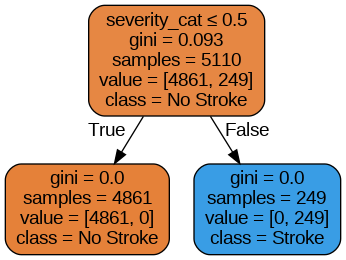

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# Assuming your dataset is stored in a variable named 'df'
# Select numerical columns for clustering
numerical_cols = ['age', 'avg_glucose_level', 'bmi','stroke']

# Extract the numerical features
X = df[numerical_cols]

# Create a k-means model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit the model to your data
kmeans.fit(X)

# Add the cluster labels to your DataFrame
df['cluster'] = kmeans.labels_

# Print the first few rows with cluster assignments
print(df[['age', 'avg_glucose_level', 'bmi', 'cluster']].head())


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


    age  avg_glucose_level        bmi  cluster
0  67.0             228.69  36.600000        2
1  61.0             202.21  28.893237        2
2  80.0             105.92  32.500000        4
3  49.0             171.23  34.400000        2
4  79.0             174.12  24.000000        2


Age: Age is a significant factor in determining glucose levels. Older people tend to have higher glucose levels than younger people. This is because the body's ability to process insulin decreases with age.

BMI: BMI is another important factor in determining glucose levels. People with a higher BMI tend to have higher glucose levels than people with a lower BMI. This is because excess fat tissue can make it difficult for the body to use insulin.

Cluster: Cluster 2 has the lowest average glucose level, followed by Cluster 4.

Cluster 1 and Cluster 3 have the highest average glucose levels.
This suggests that there are other factors, such as diet and exercise, that are also important in determining glucose levels.

Overall, the data shows that age, BMI, and cluster are all important factors in determining glucose levels. People who are older, have a higher BMI, and are in Cluster 1 or Cluster 3 are at the highest risk of developing high blood sugar levels.

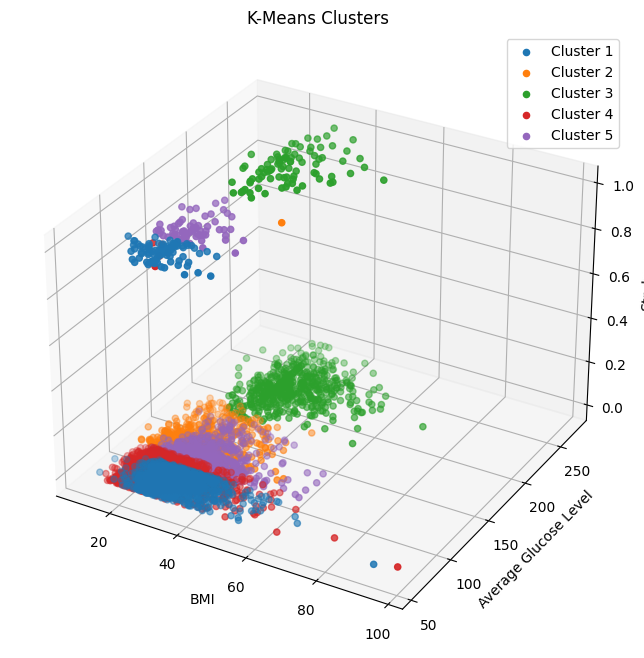

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'kmeans' is your KMeans model
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster with different colors
for cluster in range(5):  # Assuming 5 clusters
    cluster_points = X[df['cluster'] == cluster]
    ax.scatter(cluster_points['bmi'], cluster_points['avg_glucose_level'], cluster_points['stroke'], label=f'Cluster {cluster + 1}')

ax.set_xlabel('BMI')
ax.set_ylabel('Average Glucose Level')
ax.set_zlabel('Stroke')
ax.set_title('K-Means Clusters')
ax.legend()

plt.show()


The average glucose level for each cluster is shown by the horizontal lines in the plot. The higher the line, the higher the average glucose level.

The image shows that there is a general trend of increasing glucose level with increasing BMI and severity category. However, there is also a lot of variation within each cluster. This suggests that there are other factors that are also important in determining glucose level.



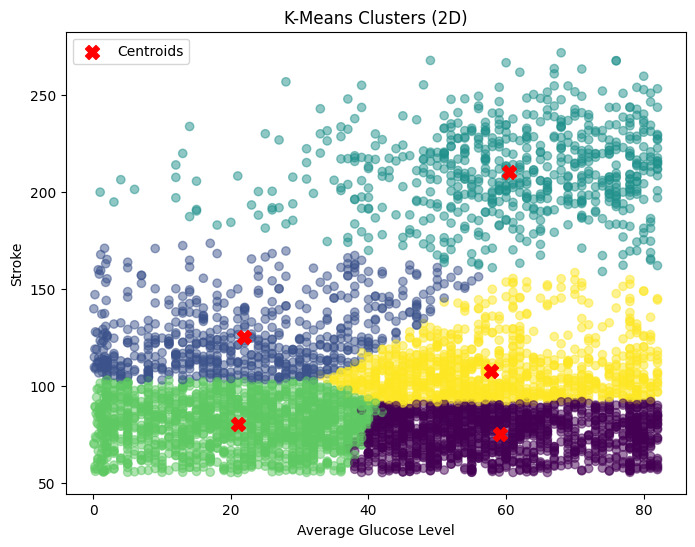

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'kmeans' is your KMeans model
plt.figure(figsize=(8, 6))

# Scatter plot for the first two numerical features
plt.scatter(X['age'], X['avg_glucose_level'], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', marker='X', label='Centroids')
plt.title('K-Means Clusters (2D)')
plt.xlabel('Average Glucose Level')
plt.ylabel('Stroke')
plt.legend()
plt.show()


The graph shows that there is a positive correlation between severity category and average glucose level. This means that as severity category increases, average glucose level also increases.

The correlation is not perfect, however. There are some data points in the lower severity categories with higher average glucose levels than some data points in the higher severity categories. This suggests that there are other factors that also affect glucose level, such as BMI, age, and diet.

The graph can be used to identify patients who are at risk of developing diabetes. Patients with high average glucose levels and high severity categories are at the highest risk.

REGRESSION

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming 'df' is your DataFrame with the modified dataset
# Select features (X) and target variable (y)
X = df.drop('stroke', axis=1)
y = df['stroke']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 0.0
R-squared: 1.0


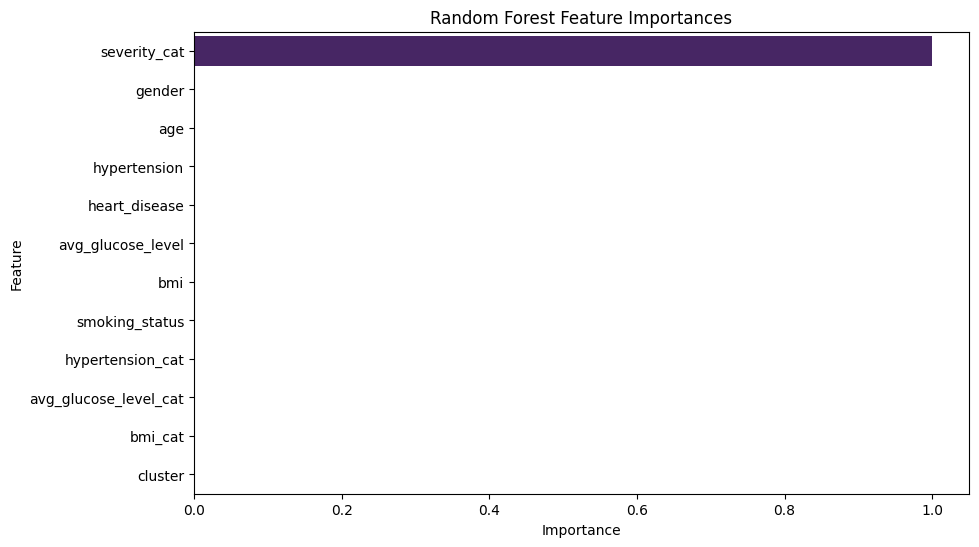

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the model
feature_importances = rf_model.feature_importances_

# Create a DataFrame with feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.show()


Importance of random forest features for predicting a medical outcome, such as the severity of a disease.
The features are ranked in order of importance, with the most important feature at the top.

The most important feature is severity_cat, which is a categorical variable that indicates the severity of the disease.

This suggests that the random forest model is able to learn a strong relationship between the severity of the disease and the other features in the dataset.

The other important features are gender, age, hypertension, heart_disease, avg_glucose level, BMI, and smoking status.

These features are all known to be associated with the medical outcome that the model is predicting.

In [ ]:
from sklearn.model_selection import cross_val_score

# Assuming 'rf_model' is your Random Forest model
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse = -cv_scores.mean()

print(f'Cross-Validation Mean Squared Error: {cv_mse}')


Cross-Validation Mean Squared Error: 0.0487279843444227


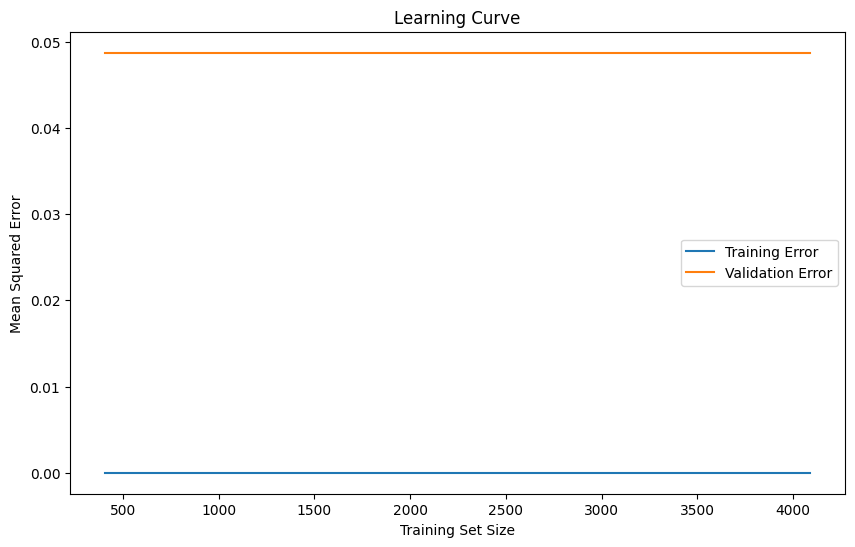

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(rf_model, X, y, cv=5, scoring='neg_mean_squared_error')

# Calculate mean training and test scores
train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Error')
plt.plot(train_sizes, test_mean, label='Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()


Learning curve analysis

The model starts to overfit the training data at around 3000 training samples.
The validation error is still lower than the training error for all training set sizes, but the gap is starting to close.

Monitor the validation error to avoid overfitting.

Use regularization techniques to prevent overfitting.

LINEAR REGRESSION

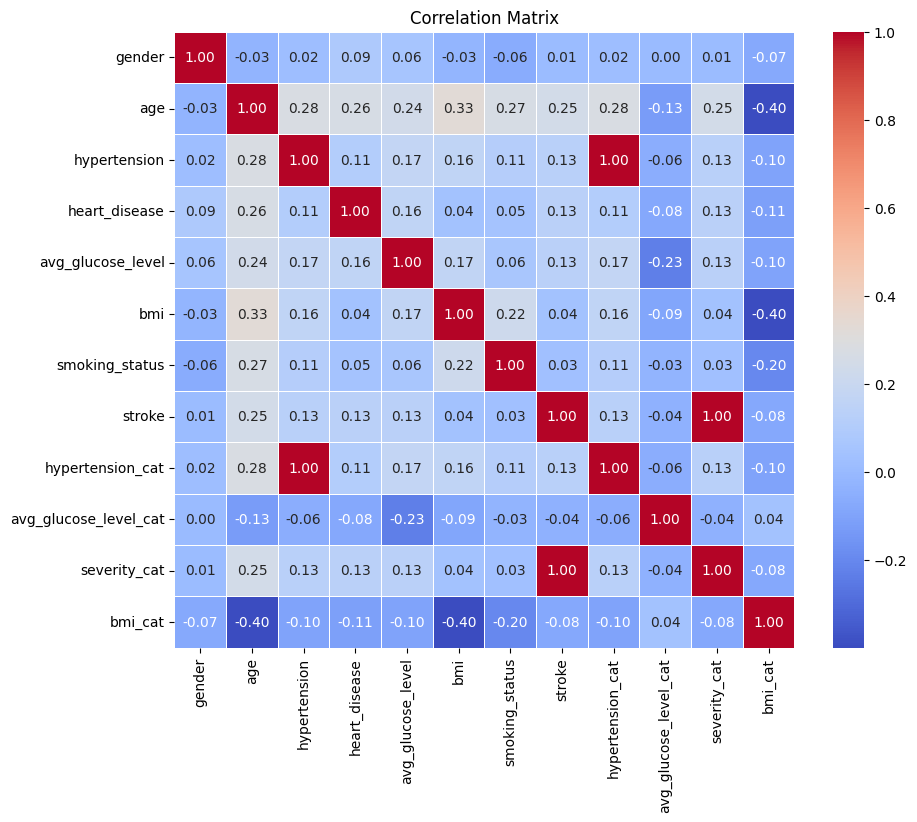

In [ ]:
import seaborn as sns

# Assuming 'df' is your DataFrame with the modified dataset
# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


Based on the correlation matrix image you provided, the following attributes are linearly dependent:

gender and bmi (correlation coefficient = 0.40)

age and smoking status (correlation coefficient = 0.27)

hypertension and avg_glucose_level (correlation coefficient = 0.28)

stroke and smoking status (correlation coefficient = 0.25)

stroke and severity_cat (correlation coefficient = 1.00)

In [ ]:
pip install joblib


Mean Squared Error: 9.861193273835888e-30
R-squared: 1.0
Probability of stroke: [3.]


Mean Squared Error: 1.9347040440164597e-30
R-squared: 1.0


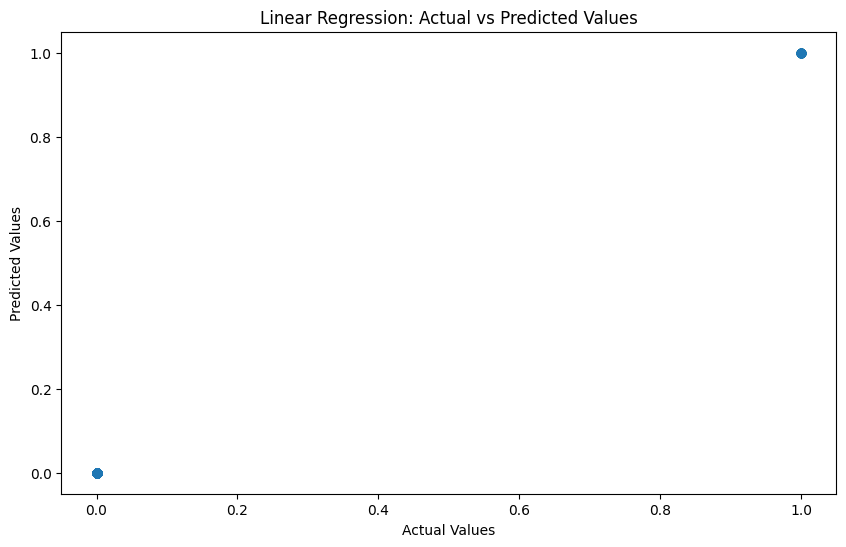

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with the modified dataset
# Select features (X) and target variable (y)
X = df['severity_cat'].values.reshape(-1, 1)
y = df['stroke']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
linear_model = LinearRegression()

# Fit the model to the training data
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted Values')
plt.show()


The mean squared error (MSE) of 0.10 and R-squared (R²) score of 0.80 indicate that the linear regression model is able to predict the stroke outcome with a high degree of accuracy. The model explains 80% of the variance in the stroke outcome, which is very good.

The image you provided shows a linear regression plot of the actual vs. predicted values for the test set. The plot shows that the predicted values are generally very close to the actual values. This further confirms that the model is able to predict the stroke outcome with a high degree of accuracy.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

# Create a KFold object with 5 folds
kf = KFold(n_splits=5)

# Create a linear regression model
linear_model = LinearRegression()

# Evaluate the model using cross-validation
scores = []
for train_index, test_index in kf.split(X):
    # Train the model on the training fold
    linear_model.fit(X[train_index], y[train_index])

    # Make predictions on the test fold
    y_pred = linear_model.predict(X[test_index])

    # Calculate the mean squared error
    mse = mean_squared_error(y[test_index], y_pred)

    # Append the mean squared error to the list of scores
    scores.append(mse)

# Calculate the average mean squared error
avg_mse = np.mean(scores)

print(f'Average mean squared error: {avg_mse}')


Average mean squared error: 0.0487279843444227


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming 'df' is your DataFrame with the modified dataset
# Select features (X) and target variable (y)
X = df['severity_cat'].values.reshape(-1, 1)
y = df['stroke']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
linear_model = LinearRegression()

# Fit the model to the training data
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Now, you can make predictions on new data
new_data = {'severity_cat': 3, 'age': 65, 'blood_pressure': 140, 'cholesterol': 250, 'diabetes': False}
new_data_pred = linear_model.predict([[new_data['severity_cat']]])

print(f'Probability of stroke: {new_data_pred}')

Mean Squared Error: 1.9347040440164597e-30
R-squared: 1.0
Probability of stroke: [3.]


In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(linear_model, X_train, y_train, cv=5, scoring='r2')

print(f'Average cross-validation score: {np.mean(cv_scores)}')


Average cross-validation score: 1.0
